In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# === BASE PROJECT DIRECTORY (YOUR DIRECTORY) ===
BASE_DIR = r"C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project"

# === FILE PATHS ===
FILES = {
    "admissions": os.path.join(BASE_DIR, "admissions.csv"),
    "diagnoses": os.path.join(BASE_DIR, "diagnoses_icd.csv"),
    "procedures": os.path.join(BASE_DIR, "procedures_icd.csv"),
    "microbiology": os.path.join(BASE_DIR, "microbiologyevents.csv"),
    "services": os.path.join(BASE_DIR, "services.csv"),
}

# === FIGURES DIRECTORY ===
FIG_DIR = os.path.join(BASE_DIR, "figures", "part1")
os.makedirs(FIG_DIR, exist_ok=True)

print("Dataset files:")
for name, path in FILES.items():
    print(f"{name}: {path}")

print("\nFigures will be saved to:", FIG_DIR)

Dataset files:
admissions: C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project\admissions.csv
diagnoses: C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project\diagnoses_icd.csv
procedures: C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project\procedures_icd.csv
microbiology: C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project\microbiologyevents.csv
services: C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project\services.csv

Figures will be saved to: C:\Users\muham\OneDrive\Desktop\Desktop 11032025\PhD Computer Science\DV\Final-Project\figures\part1


In [3]:
dfs = {}  # dictionary of DataFrames

for name, path in FILES.items():
    print(f"Loading: {name} ...")
    dfs[name] = pd.read_csv(path, low_memory=False)
    print(f" → Loaded {dfs[name].shape[0]:,} rows and {dfs[name].shape[1]} columns\n")

admissions = dfs["admissions"]
diagnoses = dfs["diagnoses"]
procedures = dfs["procedures"]
microbiology = dfs["microbiology"]
services = dfs["services"]

Loading: admissions ...
 → Loaded 431,088 rows and 15 columns

Loading: diagnoses ...
 → Loaded 4,752,265 rows and 5 columns

Loading: procedures ...
 → Loaded 668,993 rows and 6 columns

Loading: microbiology ...
 → Loaded 3,223,345 rows and 24 columns

Loading: services ...
 → Loaded 467,851 rows and 5 columns



In [4]:
for name, df in dfs.items():
    print("="*80)
    print(f"TABLE: {name.upper()}")
    print("="*80)
    print(df.info())
    print("\n")

TABLE: ADMISSIONS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431088 entries, 0 to 431087
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   subject_id            431088 non-null  int64 
 1   hadm_id               431088 non-null  int64 
 2   admittime             431088 non-null  object
 3   dischtime             431088 non-null  object
 4   deathtime             8625 non-null    object
 5   admission_type        431088 non-null  object
 6   admission_location    431088 non-null  object
 7   discharge_location    311774 non-null  object
 8   insurance             431088 non-null  object
 9   language              431088 non-null  object
 10  marital_status        421868 non-null  object
 11  race                  431088 non-null  object
 12  edregtime             299260 non-null  object
 13  edouttime             299260 non-null  object
 14  hospital_expire_flag  431088 non-null  int64 
dtyp

In [5]:
for name, df in dfs.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print(f"\n=== {name.upper()} — Numeric Summary ===")
    display(df[numeric_cols].describe().T)


=== ADMISSIONS — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
subject_id,431088.0,1.500399e+07,2.881215e+06,10000032.0,12504643.75,15012885.0,17500197.0,19999987.0
hadm_id,431088.0,2.500043e+07,2.887800e+06,20000019.0,22499332.25,25002558.0,27501667.0,29999928.0
hospital_expire_flag,431088.0,2.003767e-02,1.401293e-01,0.0,0.00,0.0,0.0,1.0



=== DIAGNOSES — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
subject_id,4752265.0,1.500027e+07,2.882984e+06,10000032.0,12494426.0,15001340.0,17507847.0,19999987.0
hadm_id,4752265.0,2.499930e+07,2.887964e+06,20000019.0,22498042.0,25000826.0,27500503.0,29999928.0
seq_num,4752265.0,8.418716e+00,6.556125e+00,1.0,3.0,7.0,12.0,39.0
icd_version,4752265.0,9.417024e+00,4.930669e-01,9.0,9.0,9.0,10.0,10.0



=== PROCEDURES — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
subject_id,668993.0,1.500223e+07,2.883591e+06,10000032.0,12499883.0,15002293.0,17502799.0,19999987.0
hadm_id,668993.0,2.500552e+07,2.883548e+06,20000041.0,22519248.0,25008573.0,27504398.0,29999828.0
seq_num,668993.0,3.212618e+00,3.171508e+00,1.0,1.0,2.0,4.0,41.0
icd_version,668993.0,9.332977e+00,4.712786e-01,9.0,9.0,9.0,10.0,10.0



=== MICROBIOLOGY — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
microevent_id,3223345.0,1.611673e+06,9.304997e+05,1.00,805837.0,1611673.0,2417509.0,3223345.0
subject_id,3223345.0,1.500215e+07,2.890589e+06,10000032.00,12493741.0,14988897.0,17520485.0,19999987.0
hadm_id,1396273.0,2.501319e+07,2.882270e+06,20000019.00,22531458.0,25017711.0,27499142.0,29999828.0
micro_specimen_id,3223345.0,4.996807e+06,2.887632e+06,1.00,2496923.0,4989372.0,7501724.0,9999993.0
spec_itemid,3223345.0,7.012746e+04,1.245195e+03,70002.00,70017.0,70064.0,70079.0,90935.0
test_seq,3223345.0,1.460432e+00,1.028570e+00,1.00,1.0,1.0,2.0,24.0
test_itemid,3223345.0,9.014029e+04,8.927560e+01,90038.00,90039.0,90175.0,90201.0,90272.0
org_itemid,1285434.0,8.064334e+04,2.476168e+03,80002.00,80002.0,80017.0,80053.0,90984.0
isolate_num,1285434.0,1.062669e+00,2.616543e-01,1.00,1.0,1.0,1.0,6.0
ab_itemid,1106436.0,9.001596e+04,7.851962e+00,90003.00,90010.0,90015.0,90022.0,90031.0



=== SERVICES — Numeric Summary ===


,count,mean,std,min,25%,50%,75%,max
subject_id,467851.0,1.500312e+07,2.880774e+06,10000032.0,12503324.0,15007908.0,17497151.0,19999987.0
hadm_id,467851.0,2.499950e+07,2.887870e+06,20000019.0,22498928.5,25004091.0,27499013.0,29999928.0


In [6]:
for name, df in dfs.items():
    print(f"\n=== Missingness — {name.upper()} ===")
    missing = df.isna().mean().sort_values(ascending=False)
    display(missing.head(15))


=== Missingness — ADMISSIONS ===


deathtime               0.979992
edregtime               0.305803
edouttime               0.305803
discharge_location      0.276774
marital_status          0.021388
hadm_id                 0.000000
subject_id              0.000000
admission_location      0.000000
admission_type          0.000000
dischtime               0.000000
admittime               0.000000
language                0.000000
insurance               0.000000
race                    0.000000
hospital_expire_flag    0.000000
dtype: float64


=== Missingness — DIAGNOSES ===


subject_id     0.0
hadm_id        0.0
seq_num        0.0
icd_code       0.0
icd_version    0.0
dtype: float64


=== Missingness — PROCEDURES ===


subject_id     0.0
hadm_id        0.0
seq_num        0.0
chartdate      0.0
icd_code       0.0
icd_version    0.0
dtype: float64


=== Missingness — MICROBIOLOGY ===


quantity               0.999985
dilution_comparison    0.665374
dilution_value         0.665374
dilution_text          0.665177
interpretation         0.656743
ab_name                0.656743
ab_itemid              0.656743
org_name               0.601211
isolate_num            0.601211
org_itemid             0.601211
hadm_id                0.566825
comments               0.306861
charttime              0.079836
storetime              0.007782
storedate              0.003767
dtype: float64


=== Missingness — SERVICES ===


prev_service    0.918485
subject_id      0.000000
hadm_id         0.000000
transfertime    0.000000
curr_service    0.000000
dtype: float64

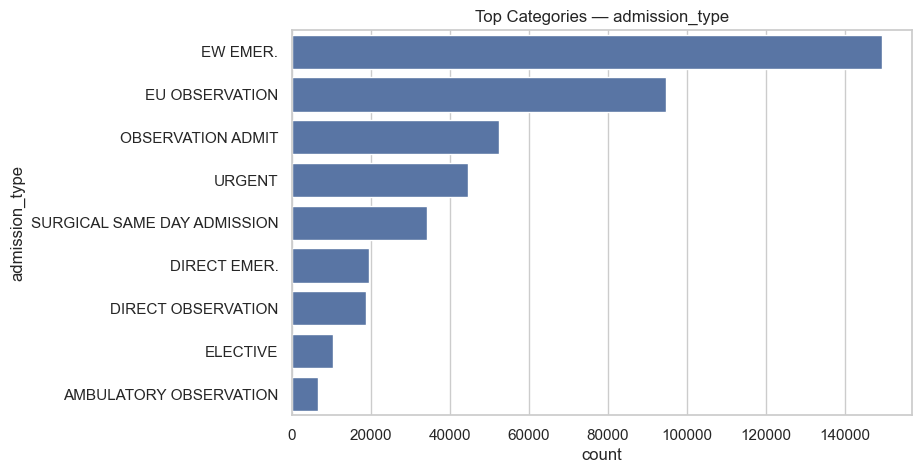

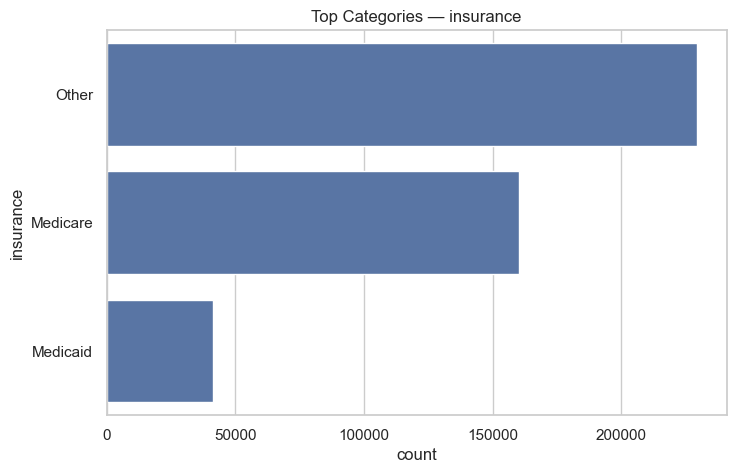

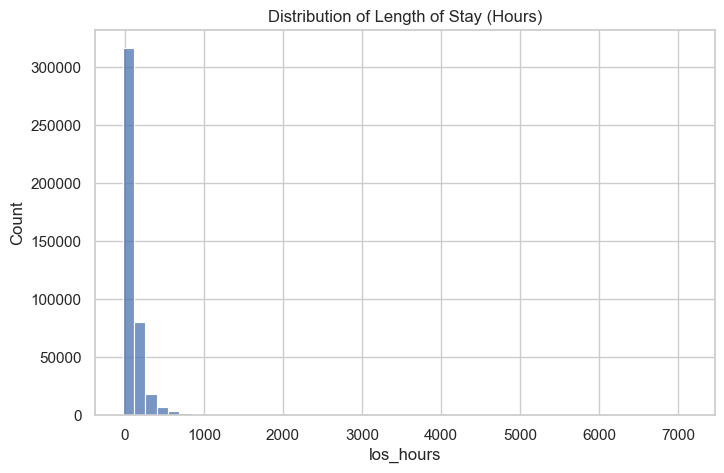

In [7]:
adm = admissions.copy()

# Try computing LOS if time columns exist
if "admittime" in adm.columns and "dischtime" in adm.columns:
    adm["admittime"] = pd.to_datetime(adm["admittime"])
    adm["dischtime"] = pd.to_datetime(adm["dischtime"])
    adm["los_hours"] = (adm["dischtime"] - adm["admittime"]).dt.total_seconds() / 3600
else:
    adm["los_hours"] = np.nan

categorical_cols = ["admission_type", "insurance", "ethnicity"]
for col in categorical_cols:
    if col in adm.columns:
        fig, ax = plt.subplots()
        sns.countplot(y=adm[col], order=adm[col].value_counts().index[:10], ax=ax)
        ax.set_title(f"Top Categories — {col}")
        fig.savefig(os.path.join(FIG_DIR, f"{col}_top10.png"))
        plt.show()

if adm["los_hours"].notna().any():
    fig, ax = plt.subplots()
    sns.histplot(adm["los_hours"], bins=50, ax=ax)
    ax.set_title("Distribution of Length of Stay (Hours)")
    fig.savefig(os.path.join(FIG_DIR, "los_distribution.png"))
    plt.show()

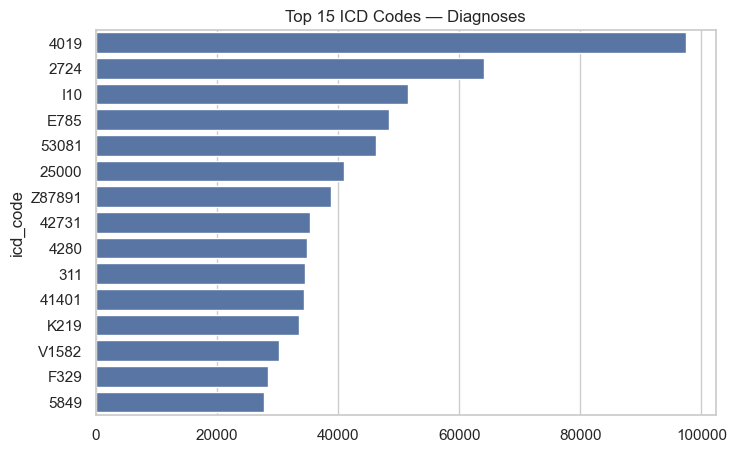

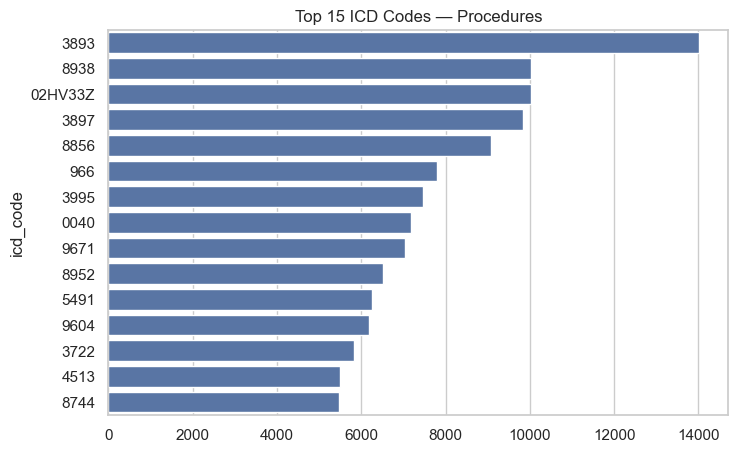

In [8]:
for name, df in [("Diagnoses", diagnoses), ("Procedures", procedures)]:
    col = "icd_code"
    if col in df.columns:
        top_codes = df[col].value_counts().head(15)
        fig, ax = plt.subplots()
        sns.barplot(x=top_codes.values, y=top_codes.index, ax=ax)
        ax.set_title(f"Top 15 ICD Codes — {name}")
        fig.savefig(os.path.join(FIG_DIR, f"top15_{name.lower()}.png"))
        plt.show()

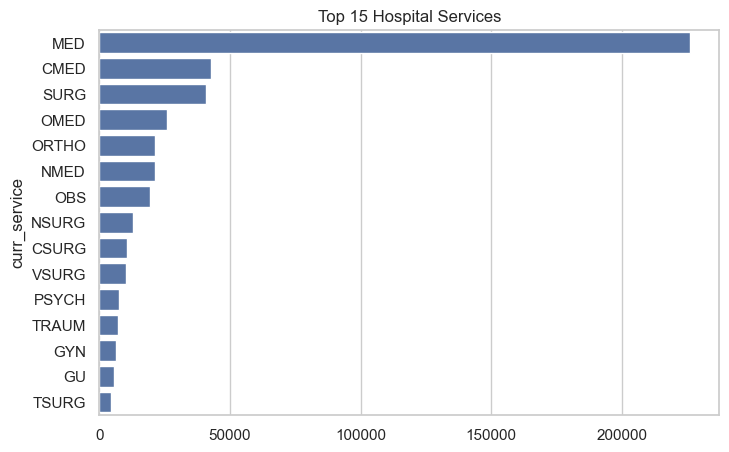

In [9]:
if "curr_service" in services.columns:
    top_services = services["curr_service"].value_counts().head(15)
    fig, ax = plt.subplots()
    sns.barplot(x=top_services.values, y=top_services.index, ax=ax)
    ax.set_title("Top 15 Hospital Services")
    fig.savefig(os.path.join(FIG_DIR, "top15_services.png"))
    plt.show()

In [10]:
if "organism" in microbiology.columns:
    top_org = microbiology["organism"].value_counts().head(15)
    fig, ax = plt.subplots()
    sns.barplot(x=top_org.values, y=top_org.index, ax=ax)
    ax.set_title("Top 15 Organisms in Microbiology Events")
    fig.savefig(os.path.join(FIG_DIR, "top15_microbiology.png"))
    plt.show()

In [11]:
keys = {
    "diagnoses": "hadm_id",
    "procedures": "hadm_id",
    "services": "hadm_id",
}

for name, key in keys.items():
    if key in dfs[name].columns:
        matches = dfs[name][key].isin(admissions["hadm_id"]).mean()
        print(f"{name}: {matches*100:.2f}% of {key} match admissions.hadm_id")

diagnoses: 100.00% of hadm_id match admissions.hadm_id
procedures: 100.00% of hadm_id match admissions.hadm_id
services: 100.00% of hadm_id match admissions.hadm_id
